In [56]:
import pandas as pd
import numpy as np
import re

In [57]:
dieutri_df = pd.read_csv("DieuTri_processed.csv")
print(dieutri_df.shape)
dieutri_df.info()
dieutri_df.head()

(1008, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Tên thuốc                1008 non-null   object
 1   link                     1008 non-null   object
 2   Chỉ định                 316 non-null    object
 3   Thành phần               229 non-null    object
 4   Liều dùng                420 non-null    object
 5   Cách dùng                313 non-null    object
 6   Tác dụng phụ             716 non-null    object
 7   Chống chỉ định           944 non-null    object
 8   Thận trọng               838 non-null    object
 9   Cảnh báo                 466 non-null    object
 10  Tương tác thuốc          567 non-null    object
 11  Mang thai và cho con bú  847 non-null    object
dtypes: object(12)
memory usage: 94.6+ KB


,Tên thuốc,link,Chỉ định,Thành phần,Liều dùng,Cách dùng,Tác dụng phụ,Chống chỉ định,Thận trọng,Cảnh báo,Tương tác thuốc,Mang thai và cho con bú
0,Azelastine: thuốc điều trị viêm mũi,https://www.dieutri.vn/a/azelastine-thuoc-dieu...,NaN,NaN,"Thuốc xịt mũi 0,1% (137mcg / lần xịt). 0,15% (...",NaN,Các tác dụng phụ thường gặp Vị đắng trong miện...,Quá mẫn đã được ghi nhận.,Có thể gây suy nhược thần kinh trung ương / bu...,NaN,Azelastine có tương tác nghiêm trọng với các l...,Dữ liệu hạn chế từ kinh nghiệm sau khi đưa thu...
1,Axit acetohydroxamic: thuốc điều trị nhiễm trù...,https://www.dieutri.vn/a/axit-acetohydroxamic-...,NaN,NaN,NaN,NaN,Tác dụng phụ thường gặp Đau đầu nhẹ; 48 giờ đầ...,Quá mẫn cảm. Bệnh nhân thích nghi với phẫu thu...,Luôn sử dụng cùng với điều trị kháng sinh thíc...,Thuốc này chứa axit acetohydroxamic. Không dùn...,Axit acetohydroxamic không có tương tác nghiêm...,Không sử dụng axit acetohydroxamic trong thai ...
2,Axalimogene Filolisbac: thuốc điều trị ung thư...,https://www.dieutri.vn/a/axalimogene-filolisba...,NaN,NaN,Axalimogene filolisbac đang trong quá trình th...,NaN,Mệt mỏi. Ớn lạnh. Sốt. Buồn nôn. Đau đầu. Hạ h...,Không có thông tin.,Không có thông tin.,Thuốc này chứa axalimogene filolisbac. Không d...,Axalimogene filolisbac đang trong quá trình th...,Axalimogene filolisbac đang trong quá trình th...
3,Avelumab: thuốc điều trị ung thư,https://www.dieutri.vn/a/avelumab-thuoc-dieu-t...,NaN,NaN,Thuốc tiêm: 20mg / ml (lọ đơn liều 200mg / 10m...,NaN,Viêm tụy. Viêm cơ tim. Viêm cơ. Suy tim sung h...,Không có.,Độc tính trên phôi thai có thể xảy ra dựa trên...,Thuốc này có chứa avelumab. Không dùng Bavenci...,Avelumab không có tương tác nghiêm trọng được ...,"Dựa trên cơ chế hoạt động của nó, có thể gây h..."
4,Atovaquone Proguanil: thuốc điều trị sốt rét,https://www.dieutri.vn/a/atovaquone-proguanil-...,NaN,NaN,NaN,NaN,"Không có. Đau dạ dày, Ăn mất ngon, Mệt mỏi, Ng...",Quá mẫn cảm. Dự phòng ở người suy thận nặng (C...,Sử dụng thuốc này không là một phương pháp chữ...,NaN,Atovaquone / Proguanil có những tương tác nghi...,Thận trọng khi sử dụng nếu lợi ích mang lại nh...


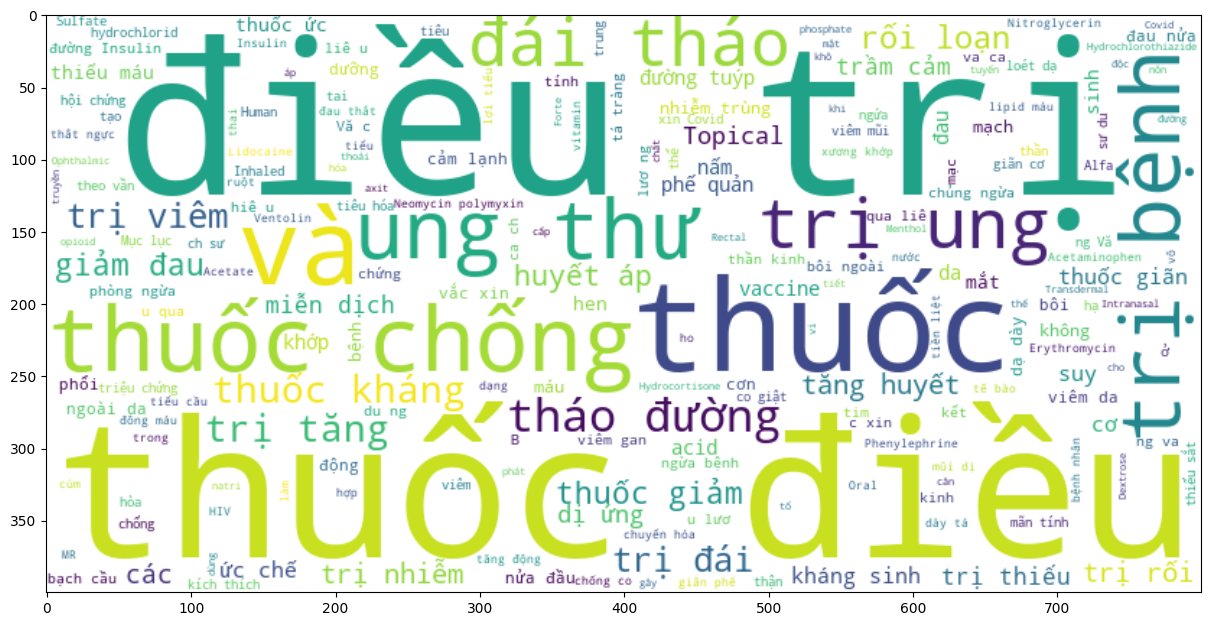

In [58]:
# Vẽ cloud tên thuốc
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Tạo một chuỗi chứa tất cả tên thuốc
text = ' '.join(dieutri_df['Tên thuốc'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')

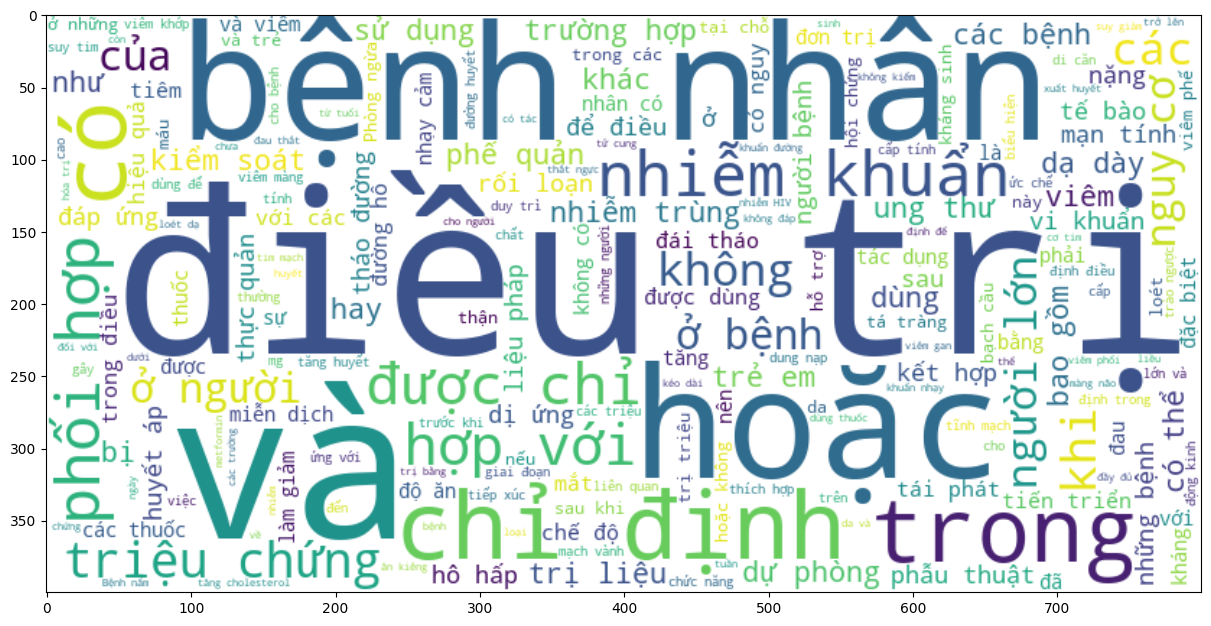

In [59]:
# Vẽ word cloud theo chỉ định
text = ' '.join(dieutri_df['Chỉ định'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')

In [60]:
# Bổ sung category theo tên thuốc và chỉ định
category_keywords = {

    'Da liễu': [
        'da','vảy nến','viêm da','chàm','mụn','dị ứng','nấm da',
        'viêm da cơ địa','ngứa','phát ban','viêm nang lông',
        'bôi ngoài','nhiễm nấm'
    ],

    'Hô hấp': [
        'phổi','hô hấp','hen','hen suyễn','viêm phế quản','viêm phổi',
        'khó thở','ho','ho khan','ho có đờm','cúm','viêm đường hô hấp',
        'viêm họng','viêm mũi','ngạt mũi','sổ mũi'
    ],

    'Tiêu hóa': [
        'dạ dày','ruột','gan','tiêu hóa','đau bụng','tiêu chảy',
        'nôn','ợ chua','trào ngược','viêm loét dạ dày',
        'đầy hơi','khó tiêu','táo bón','viêm đại tràng'
    ],

    'Thần kinh/Tâm thần': [
        'thần kinh','tâm thần','trầm cảm','lo âu','mất ngủ',
        'động kinh','co giật','rối loạn','đau đầu',
        'đau nửa đầu','chóng mặt','sa sút trí tuệ'
    ],

    'Cơ xương khớp': [
        'cơ','xương','khớp','đau lưng','thoái hóa',
        'gout','viêm khớp','đau cơ','viêm gân',
        'thoái hóa khớp','đau vai','đau cổ'
    ],

    'Tim mạch': [
        'tim','mạch','huyết áp','tăng huyết áp','hạ huyết áp',
        'đột quỵ','suy tim','rối loạn nhịp','nhồi máu',
        'động mạch','tĩnh mạch','đau thắt ngực'
    ],

    'Nội tiết': [
        'tiểu đường','đái tháo đường','insulin',
        'nội tiết','hormone','đường huyết',
        'tuyến giáp','cường giáp','suy giáp'
    ],

    'Ung thư': [
        'ung thư','khối u','di căn','tế bào ung thư',
        'hóa trị','xạ trị','ung thư phổi','ung thư gan',
        'ung thư vú'
    ],

    'Mắt/Tai/Mũi/Họng': [
        'mắt','tai','mũi','họng',
        'viêm mũi','viêm họng','viêm tai',
        'viêm kết mạc','thị lực','ù tai',
        'đau tai','khô mắt'
    ],

    'Viêm nhiễm': [
        'viêm','nhiễm trùng','virus','vi khuẩn',
        'nhiễm khuẩn','nhiễm nấm','nhiễm virus',
        'viêm cấp','viêm mãn'
    ],

    'Kháng sinh': [
        'kháng sinh','antibiotic',
        'amoxicillin','cephalosporin','penicillin',
        'azithromycin','erythromycin'
    ],

    'Vitamin/Khoáng chất': [
        'vitamin','dinh dưỡng','bổ sung',
        'vitamin c','vitamin d','vitamin b',
        'canxi','sắt','kẽm','magie'
    ],

    'Tiết niệu': [
        'tiết niệu','thận','bàng quang',
        'sỏi thận','sỏi tiết niệu',
        'nhiễm trùng tiểu','tiểu buốt',
        'tiểu rắt','tiểu đêm'
    ],

    'Máu': [
        'máu','thiếu máu','huyết khối',
        'đông máu','chống đông',
        'thiếu sắt'
    ],

    'Dị ứng/Miễn dịch': [
        'dị ứng','mẫn cảm','miễn dịch',
        'phản vệ','viêm dị ứng'
    ],

    'Giảm đau/Hạ sốt': [
        'giảm đau','hạ sốt','paracetamol',
        'ibuprofen','đau','sốt',
        'đau đầu','đau răng'
    ],

    'Khác': []
}

In [61]:
def score_category_from_text(text, category_keywords):
    if pd.isna(text):
        return {}
    
    text_lower = str(text).lower()
    scores = {}

    for category, keywords in category_keywords.items():
        if category == "Khác":
            continue
        score = 0

        for keyword in keywords:
            count = len(re.findall(rf'\b{re.escape(keyword)}\b', text_lower))
            score += count
        if score > 0:
            scores[category] = score
    return scores
    

In [62]:
def assign_category_hybrid(row, category_keywords):
    name_scores = score_category_from_text(row['Tên thuốc'], category_keywords)

    indication_scores = score_category_from_text(row['Chỉ định'], category_keywords)

    combined_scores = {}
    for category, score in name_scores.items():
        combined_scores[category] = combined_scores.get(category, 0) + score * 2

    for category, score in indication_scores.items():
        combined_scores[category] = combined_scores.get(category, 0) + score
    
    if combined_scores:
        best_category = max(combined_scores, key=combined_scores.get)
        return best_category
    return "Khác"

In [63]:
dieutri_df['Category'] = dieutri_df.apply(lambda row: assign_category_hybrid(row, category_keywords), axis=1)
print(dieutri_df['Category'].value_counts())

Category
Khác                   391
Viêm nhiễm              65
Thần kinh/Tâm thần      64
Tim mạch                58
Da liễu                 55
Tiêu hóa                54
Ung thư                 54
Cơ xương khớp           51
Nội tiết                41
Mắt/Tai/Mũi/Họng        38
Hô hấp                  37
Máu                     35
Giảm đau/Hạ sốt         29
Dị ứng/Miễn dịch        11
Vitamin/Khoáng chất      9
Kháng sinh               9
Tiết niệu                7
Name: count, dtype: int64


In [64]:
dieutri_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Tên thuốc                1008 non-null   object
 1   link                     1008 non-null   object
 2   Chỉ định                 316 non-null    object
 3   Thành phần               229 non-null    object
 4   Liều dùng                420 non-null    object
 5   Cách dùng                313 non-null    object
 6   Tác dụng phụ             716 non-null    object
 7   Chống chỉ định           944 non-null    object
 8   Thận trọng               838 non-null    object
 9   Cảnh báo                 466 non-null    object
 10  Tương tác thuốc          567 non-null    object
 11  Mang thai và cho con bú  847 non-null    object
 12  Category                 1008 non-null   object
dtypes: object(13)
memory usage: 102.5+ KB


In [65]:
dieutri_df.to_csv("Dieutri_processed_with_category.csv")
